# Library imports

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [2]:
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

# Loading the datasets for analysis

In [3]:
amazon_df = pd.read_csv("../data/amazon.csv")

## Example view of data to deduce the structure and schema of the dataset

In [4]:
amazon_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Dataset check for nulls and duplicates

In [5]:
amazon_df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [6]:
amazon_df.duplicated().sum()

np.int64(0)

## Cleaning numeric data as part of pre-processing

In [7]:
amazon_df["discounted_price"] = (
    amazon_df["discounted_price"]
    .str.replace("₹","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

amazon_df["actual_price"] = (
    amazon_df["actual_price"]
    .str.replace("₹","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

amazon_df["discount_percentage"] = (
    amazon_df["discount_percentage"]
    .str.replace("%","", regex=False)
    .astype(float)
)

amazon_df["rating_count"] = (
    amazon_df["rating_count"]
    .astype(str)
    .str.replace(",","", regex=False)
)

amazon_df["rating_count"] = pd.to_numeric(amazon_df["rating_count"], errors="coerce")
amazon_df["rating"] = pd.to_numeric(amazon_df["rating"], errors="coerce")

### Cleaned data example view

In [8]:
amazon_df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59.0,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25.0,4.1,4118.0,"230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but th

## Segmenting dataset by main category and sub category for better and efficient categorical analysis

In [9]:
amazon_df["main_category"] = amazon_df["category"].str.split("|").str[0]
amazon_df["sub_category"] = amazon_df["category"].str.split("|").str[1]

## Deduction of average price, average rating, total product count by main category

In [10]:
amazon_df.groupby("main_category").agg(
    avg_price=("discounted_price", "mean"),
    avg_rating=("rating", "mean"),
    total_products=("product_name", "count"),
).round(2).sort_values("total_products", ascending=False)

,avg_price,avg_rating,total_products
main_category,,,
Electronics,5965.89,4.08,526
Computers&Accessories,842.65,4.15,453
Home&Kitchen,2330.62,4.04,448
OfficeProducts,301.58,4.31,31
HomeImprovement,337.00,4.25,2
MusicalInstruments,638.00,3.90,2
Car&Motorbike,2339.00,3.80,1
Health&PersonalCare,899.00,4.00,1
Toys&Games,150.00,4.30,1


## Deduction of average price, average rating and total product count by sub category

In [11]:
amazon_df.groupby(["main_category", "sub_category"]).agg(
    avg_price=("discounted_price", "mean"),
    avg_rating=("rating", "mean"),
    total_products=("product_name", "count"),
).round(2).sort_values(["main_category", "sub_category", "total_products"], ascending=False)

avg_price  avg_rating  total_products
main_category         sub_category                                                                  
Toys&Games            Arts&Crafts                                 150.00        4.30               1
OfficeProducts        OfficePaperProducts                         242.85        4.29              27
                      OfficeElectronics                           698.00        4.45               4
MusicalInstruments    Microphones                                 638.00        3.90               2
HomeImprovement       Electrical                                  337.00        4.25               2
Home&Kitchen          Kitchen&HomeAppliances                     2153.08        4.05             308
                      Kitchen&Dining                              199.00        4.10               1
                      HomeStorage&Organization                    358.00        4.03              16
                      Heating,Cooling&AirQuality                 3222.32        3.99             116
                      CraftMaterials                              178.57        4.34               7
Health&PersonalCare   HomeMedicalSupplies&Equipment               899.00        4.00               1
Electronics           WearableTechnology                         2339.70        4.02              76
                      PowerAccessories                           1289.00        4.50               1
                      Mobiles&Accessories                        7134.05        4.13             161
                      HomeTheater,TV&Video                      10407.12        4.08             162
                      HomeAudio                                  1546.50        4.07              16
                      Headphones,Earbuds&Accessories              948.12        3.93              66
                      GeneralPurposeBatteries&BatteryChargers     384.07        4.35              14
                      Cameras&Photography                        1272.00        4.12              16
                      Accessories                                 811.86        4.34              14
Computers&Accessories Tablets                                   26999.00        4.60               1
                      Printers,Inks&Accessories                  2785.55        3.96              11
                      NetworkingDevices                          1108.47        4.16              34
                      Monitors                                   8199.00        4.25               2
                      Laptops                                   37247.00        4.00               1
                      ExternalDevices&DataStorage                2151.39        4.32              18
                      Components                                 1764.40        4.38               5
                      Accessories&Peripherals                     486.09        4.15             381
Car&Motorbike         CarAccessories                             2339.00        3.80               1

## Mean discount by main category

In [12]:
amazon_df.groupby("main_category")["discounted_price"].mean().sort_values(ascending=False).round(2)

main_category
Electronics              5965.89
Car&Motorbike            2339.00
Home&Kitchen             2330.62
Health&PersonalCare       899.00
Computers&Accessories     842.65
MusicalInstruments        638.00
HomeImprovement           337.00
OfficeProducts            301.58
Toys&Games                150.00
Name: discounted_price, dtype: float64

## Mean discount percentage by main category

In [13]:
amazon_df.groupby("main_category")["discount_percentage"].mean().sort_values(ascending=False).round(2)

main_category
HomeImprovement          57.50
Computers&Accessories    54.02
Health&PersonalCare      53.00
Electronics              50.83
MusicalInstruments       46.00
Car&Motorbike            42.00
Home&Kitchen             40.12
OfficeProducts           12.35
Toys&Games                0.00
Name: discount_percentage, dtype: float64

## N-largest products by markdown value

In [14]:
amazon_df["markdown_value"] = amazon_df["actual_price"] - amazon_df["discounted_price"]

amazon_df.nlargest(10, "markdown_value")[[
    "product_name","main_category","actual_price","discounted_price","markdown_value"
]]

,product_name,main_category,actual_price,discounted_price,markdown_value
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Electronics,139900.0,77990.0,61910.0
1182,"Coway Professional Air Purifier for Home, Long...",Home&Kitchen,59900.0,14400.0,45500.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,74999.0,37990.0,37009.0
150,VU 138 cm (55 inches) Premium Series 4K Ultra ...,Electronics,65000.0,29990.0,35010.0
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,Home&Kitchen,75990.0,42990.0,33000.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,Electronics,79990.0,47990.0,32000.0
1306,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,Home&Kitchen,59900.0,27900.0,32000.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,Electronics,85000.0,54990.0,30010.0
108,VU 139 cm (55 inches) The GloLED Series 4K Sma...,Electronics,65000.0,37999.0,27001.0
323,TCL 108 cm (43 inches) 4K Ultra HD Certified A...,Electronics,51990.0,24990.0,27000.0


## Highest rated product

In [15]:
amazon_df[amazon_df["rating_count"] >= 1000] \
.sort_values(["rating","rating_count"], ascending=[False, False])[
["product_name","rating","rating_count"]
].head(10)

,product_name,rating,rating_count
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8,53803.0
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8,3964.0
459,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7,7779.0
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7,5935.0
1388,Campfire Spring Chef Prolix Instant Portable W...,4.7,2591.0
1275,Multifunctional 2 in 1 Electric Egg Boiling St...,4.7,2300.0
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7,1729.0
820,Redgear MP35 Speed-Type Gaming Mousepad (Black...,4.6,33434.0
447,Spigen EZ Fit Tempered Glass Screen Protector ...,4.6,26603.0
886,"Logitech M331 Silent Plus Wireless Mouse, 2.4G...",4.6,12375.0


## Highest reviewed product

In [16]:
amazon_df.nlargest(10, "rating_count")[[
    "product_name","rating_count","rating"
]]

,product_name,rating_count,rating
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0,4.4
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0,4.4
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0,4.4
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0,4.4
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0,4.1
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0,4.1
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0,4.1
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0,4.1
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0,4.1
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832.0,4.1


### Highest rated product by main category

In [17]:
amazon_df.groupby("main_category").agg(
    total_reviews=("rating_count","sum"),
    avg_reviews_per_product=("rating_count","mean"),
    total_products=("product_name","count"),
    avg_rating=("rating","mean")
).round(2).sort_values("total_reviews", ascending=False)

,total_reviews,avg_reviews_per_product,total_products,avg_rating
main_category,,,,
Electronics,15778848.0,29997.81,526,4.08
Computers&Accessories,7728689.0,17136.78,453,4.15
Home&Kitchen,2991069.0,6676.49,448,4.04
OfficeProducts,149675.0,4828.23,31,4.31
MusicalInstruments,88882.0,44441.00,2,3.90
Toys&Games,15867.0,15867.00,1,4.30
HomeImprovement,8566.0,4283.00,2,4.25
Health&PersonalCare,3663.0,3663.00,1,4.00
Car&Motorbike,1118.0,1118.00,1,3.80


## Highest reviewed product by main category

In [18]:
summary = amazon_df.groupby("main_category").agg(
    total_reviews=("rating_count","sum")
).reset_index()

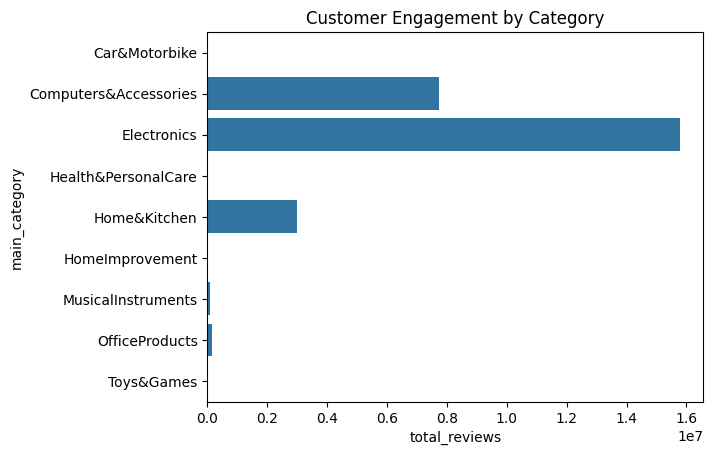

In [19]:
sns.barplot(
    data=summary.reset_index(),
    x="total_reviews",
    y="main_category"
)
plt.title("Customer Engagement by Category")
plt.show()

## Highest rated and reviewed product by sub category

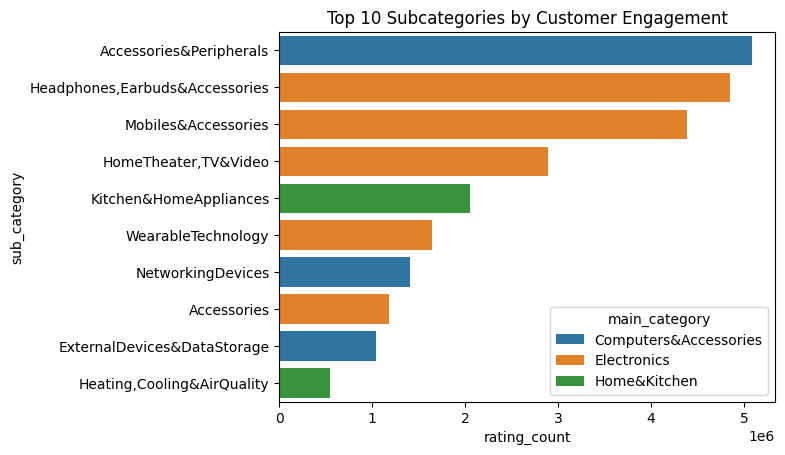

In [20]:
top_sub = amazon_df.groupby(
    ["main_category","sub_category"]
)["rating_count"].sum().reset_index()

top_sub = top_sub.sort_values(
    "rating_count",
    ascending=False
).head(10)

sns.barplot(
    data=top_sub,
    x="rating_count",
    y="sub_category",
    hue="main_category"
)

plt.title("Top 10 Subcategories by Customer Engagement")
plt.show()

### Discount Percentage vs Rating

In [21]:
amazon_df[["discount_percentage","rating"]].corr()

,discount_percentage,rating
discount_percentage,1.000000,-0.155375
rating,-0.155375,1.000000


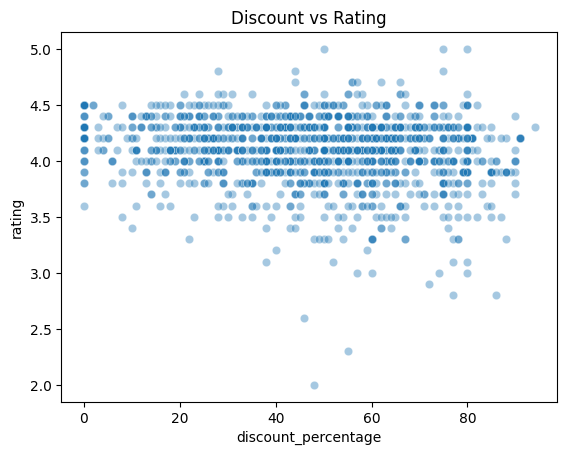

In [22]:
sns.scatterplot(
    data=amazon_df,
    x="discount_percentage",
    y="rating",
    alpha=0.4
)
plt.title("Discount vs Rating")
plt.show()

## Category-Level Discount vs Rating Relationship

We measured how discount percentages relate to customer ratings within each major category.

### Key Findings:
- Most categories show weak negative correlation.
- Larger discounts do not improve ratings.
- Product quality matters more than markdown size.
- Small categories with very few products may show unstable correlations.

In [23]:
corr_df = (
    amazon_df.groupby("main_category")[["discount_percentage", "rating"]]
    .corr()
    .reset_index()
)

corr_df = corr_df[
    (corr_df["level_1"] == "discount_percentage")
]

corr_df = corr_df[["main_category", "rating"]]
corr_df.columns = ["main_category", "correlation"]

corr_df

,main_category,correlation
0,Car&Motorbike,NaN
2,Computers&Accessories,-0.129261
4,Electronics,-0.178965
6,Health&PersonalCare,NaN
8,Home&Kitchen,-0.239087
10,HomeImprovement,1.000000
12,MusicalInstruments,1.000000
14,OfficeProducts,-0.135102
16,Toys&Games,NaN


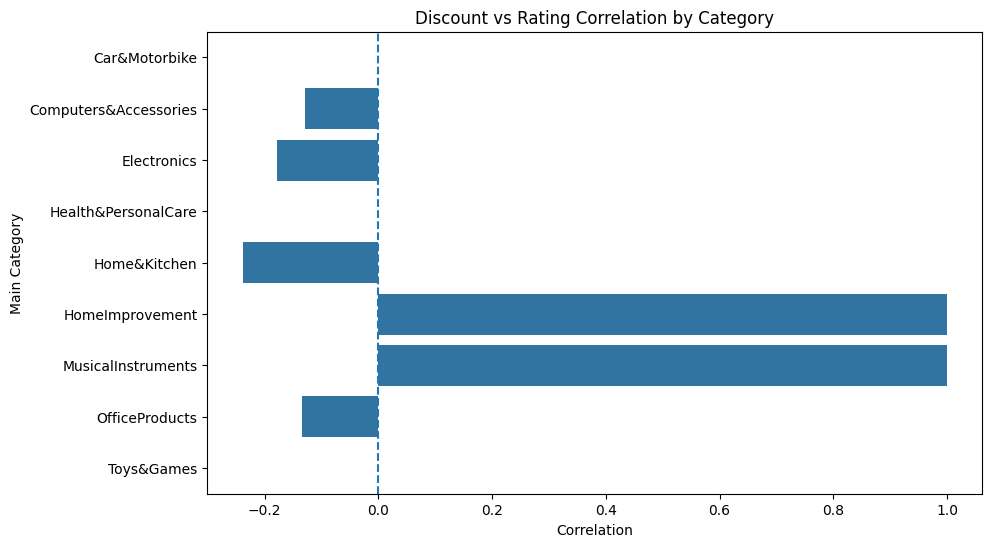

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=corr_df,
    x="correlation",
    y="main_category"
)

plt.title("Discount vs Rating Correlation by Category")
plt.xlabel("Correlation")
plt.ylabel("Main Category")
plt.axvline(0, linestyle="--")

plt.show()

In [27]:
load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")

engine = create_engine(DATABASE_URL)

In [28]:
pd.read_sql("SELECT NOW();", engine)

,now
0,2026-04-25 05:47:00.924356+00:00


In [29]:
amazon_df.to_sql(
    "products",
    engine,
    if_exists="replace",
    index=False
)

465